In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

data = torch.load('data/lichess_processed_dataset_50k.pt', weights_only=True)
tokens_tensor = data['tokens']
moves_tensor  = data['moves']
values_tensor = data['values']
print(f"Loaded {tokens_tensor.size(0)} positions from lichess_processed_dataset.pt")
print(f"Tokens: {tokens_tensor.shape} | Moves: {moves_tensor.shape} | Values: {values_tensor.shape}")

dataset = TensorDataset(tokens_tensor, moves_tensor, values_tensor)
val_fraction = 0.1
val_size = int(len(dataset) * val_fraction)
train_size = len(dataset) - val_size
split_generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=split_generator
)
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

# Optimized DataLoader settings:
# - persistent_workers=True keeps workers alive between epochs (avoids respawn overhead)
# - prefetch_factor=4 preloads more batches for smoother GPU feeding
train_loader = DataLoader(train_dataset, batch_size=870, shuffle=True,
                          pin_memory=True, num_workers=6, drop_last=False,
                          persistent_workers=True, prefetch_factor=4)
val_loader   = DataLoader(val_dataset,   batch_size=870, shuffle=False,
                          pin_memory=True, num_workers=6, drop_last=False,
                          persistent_workers=True, prefetch_factor=4)

Loaded 4156261 positions from lichess_processed_dataset.pt
Tokens: torch.Size([4156261, 68]) | Moves: torch.Size([4156261]) | Values: torch.Size([4156261])
Train size: 3740635 | Val size: 415626


In [4]:
import math
import torch
import torch.nn as nn

class ChessTransformer(nn.Module):
    def __init__(self, vocab_size=43, d_model=512, nhead=8, num_layers=8, dropout=0.1, head_dim=64):
        super().__init__()
        
        # 1. Input Embedding & Dropout
        # vocab_size is 43:
        #   0-12:  piece tokens (0=empty, 1-6=white, 7-12=black)
        #   13-14: side to move (13=white, 14=black)
        #   15-30: castling rights (16 combinations)
        #   31-39: en passant file (31=none, 32-39=a-h)
        #   40:    CLS token
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.emb_dropout = nn.Dropout(dropout)
        
        # 2. Positional Encoding
        # Sequence length is 68: 64 squares + side + castling + ep + CLS
        self.pos_encoder = nn.Parameter(torch.randn(1, 68, d_model) * 0.02)
        
        # 3. Transformer Backbone with Dropout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. The Value Head (CLS token at position 67)
        self.value_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
            nn.Tanh()
        )
        
        # 5. The Policy Head (Bilinear Interaction over first 64 tokens only)
        self.head_dim = head_dim
        self.from_proj = nn.Linear(d_model, head_dim)
        self.to_proj = nn.Linear(d_model, head_dim)
        self.logit_scale = 1.0 / math.sqrt(head_dim)

    def forward(self, x, legal_move_mask=None):
        # x shape: (Batch, 68)
        
        # Step 1 & 2: Embed, add pos encoding, and apply dropout
        x = self.embedding(x) + self.pos_encoder
        x = self.emb_dropout(x)
        
        # Step 3: Transformer
        x = self.transformer(x)  # Output shape: (Batch, 68, d_model)
        
        # Step 4: Value Head via CLS token (position 67)
        cls_state = x[:, 67, :]  # Shape: (Batch, d_model)
        value = self.value_head(cls_state).squeeze(-1)  # Shape: (Batch,)
        
        # Step 5: Policy Head via Scaled Bilinear Dot Product (first 64 tokens only)
        x_squares = x[:, :64, :]  # Shape: (Batch, 64, d_model) - board squares only
        from_feats = self.from_proj(x_squares)  # Shape: (Batch, 64, head_dim)
        to_feats = self.to_proj(x_squares)      # Shape: (Batch, 64, head_dim)
        
        # Scaled dot-product keeps softmax temperature reasonable at init
        policy_logits = torch.bmm(from_feats, to_feats.transpose(1, 2)) * self.logit_scale
        policy_logits = policy_logits.view(x.size(0), 4096)
        
        # Step 6: Legal Move Masking
        if legal_move_mask is not None:
            policy_logits = policy_logits.masked_fill(~legal_move_mask, float('-inf'))
            
        return policy_logits, value

c:\Users\Ethan Guo\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Running LR Range Test: 1.0e-07 -> 1.0e+00 over 500 batches...
  Batch 0/500 | LR: 1.00e-07 | Loss: 10.8119
  Batch 50/500 | LR: 5.01e-07 | Loss: 9.8755
  Batch 100/500 | LR: 2.51e-06 | Loss: 8.3571
  Batch 150/500 | LR: 1.26e-05 | Loss: 7.6626
  Batch 200/500 | LR: 6.31e-05 | Loss: 7.1248
  Batch 250/500 | LR: 3.16e-04 | Loss: 6.5900
  Batch 300/500 | LR: 1.58e-03 | Loss: 21.2557
Stopping at batch 306: loss diverged (best=6.5677, current=30.1584)
LR Range Test complete. Tested 307 batches.

SUGGESTED LEARNING RATES:
  - 10x below min loss point: 4.23e-05
  - Steepest descent region:  5.18e-07
  - Recommended max_lr for OneCycleLR: 5.18e-07 to 4.23e-05


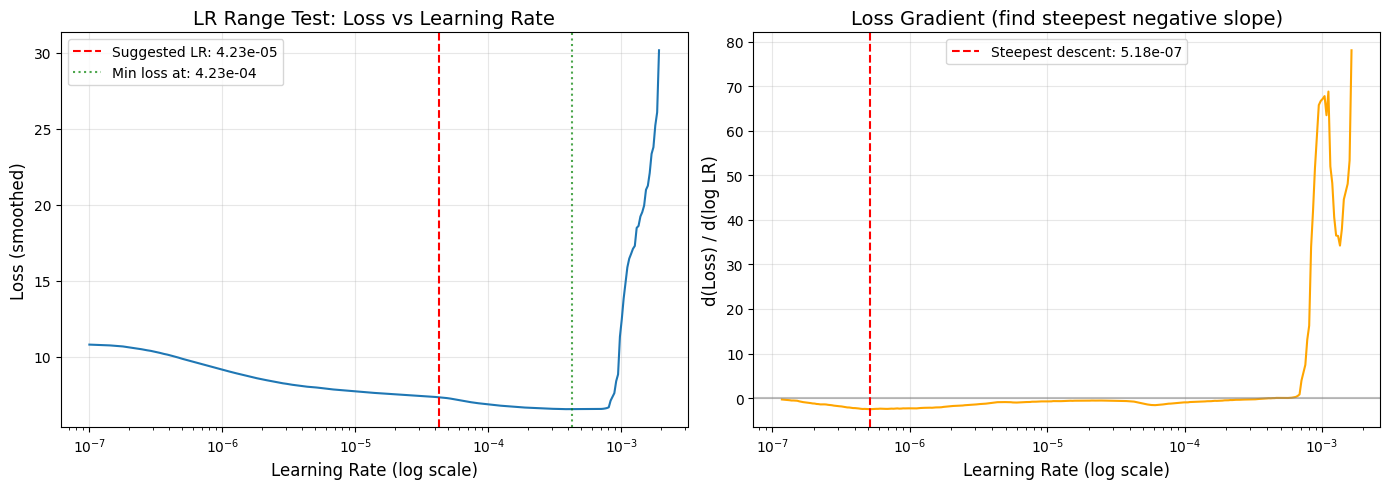

In [5]:
# =============================================================================
# LR Range Test (Learning Rate Finder)
# =============================================================================
# Sweeps LR from a small value to a large value over N batches, plotting loss
# vs LR to identify the optimal learning rate. Look for:
#   - The midpoint of the steepest descent region, OR
#   - ~10x smaller than where loss starts diverging
# =============================================================================

import math
import copy
import matplotlib.pyplot as plt
from torch.amp.autocast_mode import autocast

def lr_range_test(
    model_class,
    train_loader,
    device,
    start_lr=1e-7,
    end_lr=10,
    num_batches=300,
    smoothing=0.05,
    diverge_threshold=4.0,
):
    """
    Run LR Range Test and plot loss vs learning rate.
    
    Args:
        model_class: The model class to instantiate (e.g., ChessTransformer)
        train_loader: DataLoader for training data
        device: torch device (cuda/cpu)
        start_lr: Starting learning rate (very small)
        end_lr: Ending learning rate (large, will cause divergence)
        num_batches: Number of batches to run the test over
        smoothing: Exponential smoothing factor for loss (0 = no smoothing)
        diverge_threshold: Stop if loss exceeds best_loss * threshold
    
    Returns:
        lrs: List of learning rates
        losses: List of smoothed losses
    """
    # Create fresh model and optimizer
    model = model_class().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=start_lr, weight_decay=1e-4)
    policy_criterion = nn.CrossEntropyLoss()
    value_criterion = nn.MSELoss()
    VALUE_LOSS_WEIGHT = 0.5
    
    # LR schedule: exponential increase from start_lr to end_lr
    lr_mult = (end_lr / start_lr) ** (1 / num_batches)
    
    lrs = []
    losses = []
    best_loss = float('inf')
    smoothed_loss = None
    
    model.train()
    data_iter = iter(train_loader)
    
    print(f"Running LR Range Test: {start_lr:.1e} -> {end_lr:.1e} over {num_batches} batches...")
    
    for batch_idx in range(num_batches):
        # Get next batch (cycle if needed)
        try:
            tokens, target_moves, target_values = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            tokens, target_moves, target_values = next(data_iter)
        
        tokens = tokens.to(device, non_blocking=True)
        target_moves = target_moves.to(device, non_blocking=True)
        target_values = target_values.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast(device_type='cuda', dtype=torch.bfloat16):
            policy_logits, predicted_values = model(tokens)
            policy_loss = policy_criterion(policy_logits, target_moves)
            value_loss = value_criterion(predicted_values, target_values)
            loss = policy_loss + VALUE_LOSS_WEIGHT * value_loss
        
        # Check for NaN
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Stopping at batch {batch_idx}: loss is NaN/Inf")
            break
        
        loss.backward()
        optimizer.step()
        
        # Record
        current_lr = optimizer.param_groups[0]['lr']
        current_loss = loss.item()
        
        # Exponential smoothing
        if smoothed_loss is None:
            smoothed_loss = current_loss
        else:
            smoothed_loss = smoothing * current_loss + (1 - smoothing) * smoothed_loss
        
        lrs.append(current_lr)
        losses.append(smoothed_loss)
        
        # Track best and check for divergence
        if smoothed_loss < best_loss:
            best_loss = smoothed_loss
        
        if smoothed_loss > best_loss * diverge_threshold:
            print(f"Stopping at batch {batch_idx}: loss diverged (best={best_loss:.4f}, current={smoothed_loss:.4f})")
            break
        
        # Update LR for next iteration
        for param_group in optimizer.param_groups:
            param_group['lr'] *= lr_mult
        
        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx}/{num_batches} | LR: {current_lr:.2e} | Loss: {smoothed_loss:.4f}")
    
    print(f"LR Range Test complete. Tested {len(lrs)} batches.")
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Loss vs LR (log scale)
    ax1.plot(lrs, losses, linewidth=1.5)
    ax1.set_xscale('log')
    ax1.set_xlabel('Learning Rate (log scale)', fontsize=12)
    ax1.set_ylabel('Loss (smoothed)', fontsize=12)
    ax1.set_title('LR Range Test: Loss vs Learning Rate', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Find suggested LR (minimum loss point / 10, or steepest descent midpoint)
    min_loss_idx = losses.index(min(losses))
    suggested_lr = lrs[min_loss_idx] / 10  # 10x smaller than minimum
    ax1.axvline(x=suggested_lr, color='r', linestyle='--', label=f'Suggested LR: {suggested_lr:.2e}')
    ax1.axvline(x=lrs[min_loss_idx], color='g', linestyle=':', alpha=0.7, label=f'Min loss at: {lrs[min_loss_idx]:.2e}')
    ax1.legend()
    
    # Plot 2: Loss gradient (to find steepest descent)
    if len(losses) > 10:
        # Compute gradient of loss w.r.t. log(lr)
        log_lrs = [math.log10(lr) for lr in lrs]
        gradients = []
        window = 5
        for i in range(window, len(losses) - window):
            grad = (losses[i + window] - losses[i - window]) / (log_lrs[i + window] - log_lrs[i - window])
            gradients.append(grad)
        
        grad_lrs = lrs[window:-window]
        ax2.plot(grad_lrs, gradients, linewidth=1.5, color='orange')
        ax2.set_xscale('log')
        ax2.set_xlabel('Learning Rate (log scale)', fontsize=12)
        ax2.set_ylabel('d(Loss) / d(log LR)', fontsize=12)
        ax2.set_title('Loss Gradient (find steepest negative slope)', fontsize=14)
        ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
        ax2.grid(True, alpha=0.3)
        
        # Find steepest descent (most negative gradient)
        min_grad_idx = gradients.index(min(gradients))
        steepest_lr = grad_lrs[min_grad_idx]
        ax2.axvline(x=steepest_lr, color='r', linestyle='--', label=f'Steepest descent: {steepest_lr:.2e}')
        ax2.legend()
        
        print(f"\n{'='*60}")
        print(f"SUGGESTED LEARNING RATES:")
        print(f"  - 10x below min loss point: {suggested_lr:.2e}")
        print(f"  - Steepest descent region:  {steepest_lr:.2e}")
        print(f"  - Recommended max_lr for OneCycleLR: {steepest_lr:.2e} to {suggested_lr:.2e}")
        print(f"{'='*60}")
    
    plt.tight_layout()
    plt.show()
    
    # Cleanup
    del model, optimizer
    torch.cuda.empty_cache()
    
    return lrs, losses


# Run the LR Range Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lrs, losses = lr_range_test(
    model_class=ChessTransformer,
    train_loader=train_loader,
    device=device,
    start_lr=1e-7,
    end_lr=1.0,
    num_batches=500,
    smoothing=0.05,
)

In [ ]:
import os
import time
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp.autocast_mode import autocast
from torch.optim.lr_scheduler import OneCycleLR

# Enable cuDNN autotuning for fixed input sizes
torch.backends.cudnn.benchmark = True

# Create models directory
os.makedirs('models', exist_ok=True)

# =============================================================================
# Training Configuration
# =============================================================================
EPOCHS = 15
MAX_LR = 5e-4
ACCUM_STEPS = 1  # Gradient accumulation steps (effective_batch = batch_size * accum_steps)
VALUE_LOSS_WEIGHT = 0.5

# =============================================================================
# Initialize Device, Model, and Optimizer
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

model = ChessTransformer().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

optimizer = optim.AdamW(model.parameters(), lr=MAX_LR / 10, weight_decay=1e-4)
policy_criterion = nn.CrossEntropyLoss()
value_criterion = nn.MSELoss()

num_batches = len(train_loader)
optimizer_steps_per_epoch = math.ceil(num_batches / ACCUM_STEPS)

# OneCycleLR: steps_per_epoch = optimizer steps, not micro-batches
scheduler = OneCycleLR(
    optimizer, max_lr=MAX_LR, epochs=EPOCHS, steps_per_epoch=optimizer_steps_per_epoch
)

effective_batch = train_loader.batch_size * ACCUM_STEPS
print(f"Train batches: {num_batches:,} | Val batches: {len(val_loader):,} | Epochs: {EPOCHS}")
print(f"Batch size: {train_loader.batch_size} x {ACCUM_STEPS} accum = {effective_batch} effective")
print(f"Optimizer steps per epoch: {optimizer_steps_per_epoch:,}")
print(f"Using OneCycleLR scheduler (max_lr={MAX_LR})\n")

def train():
    best_val_loss = float('inf')
    best_val_acc = 0.0
    training_start = time.time()

    for epoch in range(EPOCHS):
        # --- Train ---
        model.train()
        epoch_start = time.time()
        total_loss = 0.0
        total_policy_loss = 0.0
        total_value_loss = 0.0
        correct_moves = 0
        total_positions = 0
        
        optimizer_step_count = 0
        # Accumulator for logging (tracks losses over accum window)
        accum_loss = 0.0
        accum_policy_loss = 0.0
        accum_value_loss = 0.0
        
        for batch_idx, (tokens, target_moves, target_values) in enumerate(train_loader):
            tokens = tokens.to(device, non_blocking=True)
            target_moves = target_moves.to(device, non_blocking=True)
            target_values = target_values.to(device, non_blocking=True)
            
            # Zero gradients only at start of accumulation window
            if batch_idx % ACCUM_STEPS == 0:
                optimizer.zero_grad(set_to_none=True)
            
            with autocast(device_type='cuda', dtype=torch.bfloat16):
                policy_logits, predicted_values = model(tokens)
                policy_loss = policy_criterion(policy_logits, target_moves)
                value_loss = value_criterion(predicted_values, target_values)
                batch_loss = policy_loss + VALUE_LOSS_WEIGHT * value_loss
            
            # Scale loss for gradient accumulation
            scaled_loss = batch_loss / ACCUM_STEPS
            scaled_loss.backward()
            
            # Track metrics (unscaled for reporting)
            total_loss += batch_loss.item()
            total_policy_loss += policy_loss.item()
            total_value_loss += value_loss.item()
            accum_loss += batch_loss.item()
            accum_policy_loss += policy_loss.item()
            accum_value_loss += value_loss.item()
            
            predictions = torch.argmax(policy_logits, dim=1)
            correct_moves += (predictions == target_moves).sum().item()
            total_positions += tokens.size(0)
            
            # Optimizer step at accumulation boundary or end of epoch
            is_accum_boundary = (batch_idx + 1) % ACCUM_STEPS == 0
            is_last_batch = (batch_idx + 1) == num_batches
            if is_accum_boundary or is_last_batch:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer_step_count += 1
                
                # Log at optimizer step boundaries
                if optimizer_step_count % 100 == 0 or optimizer_step_count == 1:
                    current_acc = (correct_moves / total_positions) * 100
                    current_lr = scheduler.get_last_lr()[0]
                    elapsed = time.time() - epoch_start
                    samples_per_sec = total_positions / elapsed if elapsed > 0 else 0
                    # Average over micro-batches in this accumulation window
                    micro_batches = (batch_idx % ACCUM_STEPS) + 1 if is_last_batch and not is_accum_boundary else ACCUM_STEPS
                    avg_loss = accum_loss / micro_batches
                    avg_policy = accum_policy_loss / micro_batches
                    avg_value = accum_value_loss / micro_batches
                    print(
                        f"Epoch {epoch+1}/{EPOCHS} | Step {optimizer_step_count}/{optimizer_steps_per_epoch} | "
                        f"Loss: {avg_loss:.4f} (P: {avg_policy:.4f}, V: {avg_value:.4f}) | "
                        f"Acc: {current_acc:.2f}% | LR: {current_lr:.2e} | "
                        f"Time: {elapsed:.1f}s | {samples_per_sec:.0f} samples/s"
                    )
                
                # Reset accumulators for next window
                accum_loss = 0.0
                accum_policy_loss = 0.0
                accum_value_loss = 0.0
        
        train_time = time.time() - epoch_start
        train_acc = (correct_moves / total_positions) * 100
        train_avg_loss = total_loss / num_batches
        train_avg_policy = total_policy_loss / num_batches
        train_avg_value = total_value_loss / num_batches
        
        # --- Validate ---
        model.eval()
        val_start = time.time()
        val_total_loss = 0.0
        val_total_policy_loss = 0.0
        val_total_value_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for tokens, target_moves, target_values in val_loader:
                tokens = tokens.to(device, non_blocking=True)
                target_moves = target_moves.to(device, non_blocking=True)
                target_values = target_values.to(device, non_blocking=True)
                
                with autocast(device_type='cuda', dtype=torch.bfloat16):
                    policy_logits, predicted_values = model(tokens)
                    policy_loss = policy_criterion(policy_logits, target_moves)
                    value_loss = value_criterion(predicted_values, target_values)
                    batch_loss = policy_loss + VALUE_LOSS_WEIGHT * value_loss
                
                val_total_loss += batch_loss.item()
                val_total_policy_loss += policy_loss.item()
                val_total_value_loss += value_loss.item()
                val_correct += (torch.argmax(policy_logits, dim=1) == target_moves).sum().item()
                val_total += tokens.size(0)
        
        val_time = time.time() - val_start
        val_acc = (val_correct / val_total) * 100
        val_avg_loss = val_total_loss / len(val_loader)
        val_avg_policy = val_total_policy_loss / len(val_loader)
        val_avg_value = val_total_value_loss / len(val_loader)
        
        print("=" * 80)
        print(
            f"Epoch {epoch+1}/{EPOCHS} Complete | "
            f"Train Loss: {train_avg_loss:.4f} (P: {train_avg_policy:.4f}, V: {train_avg_value:.4f}) Acc: {train_acc:.2f}%"
        )
        print(
            f"Val Loss: {val_avg_loss:.4f} (P: {val_avg_policy:.4f}, V: {val_avg_value:.4f}) Acc: {val_acc:.2f}% | "
            f"Time: {train_time:.1f}s train + {val_time:.1f}s val"
        )
        
        # --- Save best model with accuracy and param count in filename ---
        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            best_val_acc = val_acc
            
            params_str = f"{num_params // 1000}k" if num_params < 1_000_000 else f"{num_params / 1_000_000:.1f}M"
            checkpoint_path = f"models/guofish_{params_str}_{val_acc:.1f}p.pt"
            
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_avg_loss,
                'val_acc': val_acc,
                'num_params': num_params,
            }, checkpoint_path)
            print(f">>> New best! Saved to {checkpoint_path}")
        else:
            print(f"No improvement (best: {best_val_loss:.4f})")
        print("=" * 80 + "\n")
    
    # --- Summary ---
    total_time = time.time() - training_start
    hours, remainder = divmod(total_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    print(f"\nTraining complete! Total time: {int(hours)}h {int(minutes)}m {int(seconds)}s")
    print(f"Best validation loss: {best_val_loss:.4f}")

if __name__ == "__main__":
    train()